# 3. Análisis de negocio

En esta fase se analizan las principales métricas comerciales para identificar oportunidades de mejora y responder a las preguntas de negocio planteadas.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/superstore_clean.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015


Ventas y beneficios por categoría

In [16]:
df.groupby("Category")[["Sales","Profit"]].sum().sort_values("Sales", ascending=False)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


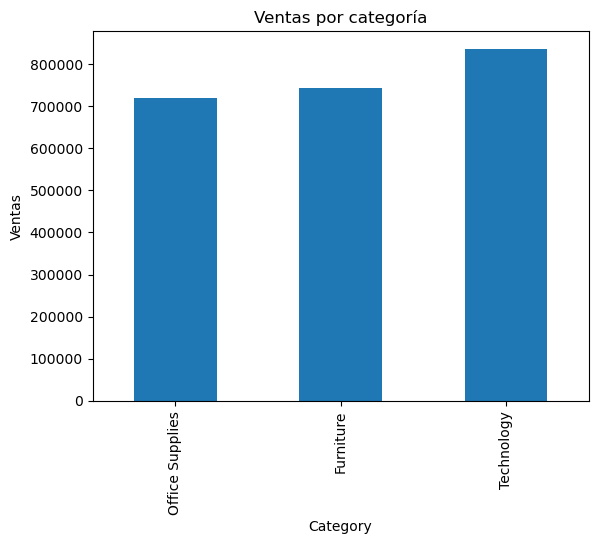

In [17]:
df.groupby("Category")["Sales"].sum().sort_values().plot(
    kind="bar"
)

plt.title("Ventas por categoría")
plt.ylabel("Ventas")
plt.show()

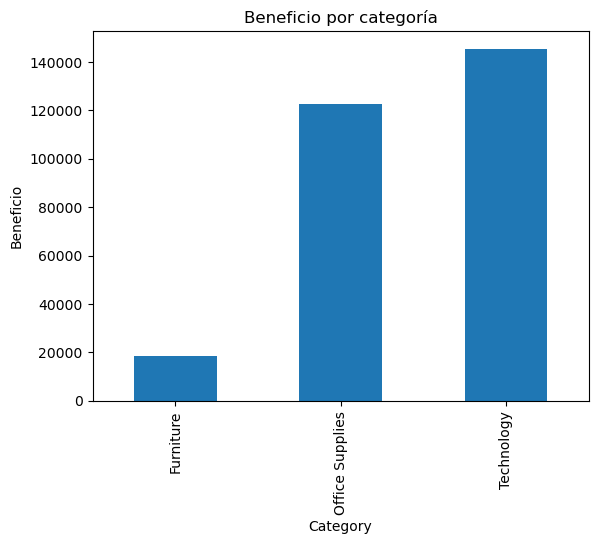

In [18]:
df.groupby("Category")["Profit"].sum().sort_values().plot(
    kind="bar"
)

plt.title("Beneficio por categoría")
plt.ylabel("Beneficio")
plt.show()

## Análisis de categorías

Technology es la categoría con mayores ventas y beneficios.

Furniture presenta un volumen de ventas elevado, pero su beneficio es considerablemente menor, lo que indica una menor rentabilidad.

Rentabilidad por categoría

In [19]:
category_analysis = df.groupby("Category")[["Sales","Profit"]].sum()

category_analysis["Profit_Margin"] = (
    category_analysis["Profit"] /
    category_analysis["Sales"]
) * 100

category_analysis.sort_values(
    "Profit_Margin",
    ascending=False
)

,Sales,Profit,Profit_Margin
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


## Margen de beneficio por categoría

Technology y Office Supplies presentan los mayores márgenes de beneficio.

Furniture muestra el margen más bajo, por lo que podría requerir una revisión de precios o descuentos.

## Beneficio por subcategoría

In [20]:
df.groupby("Sub-Category")["Profit"].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

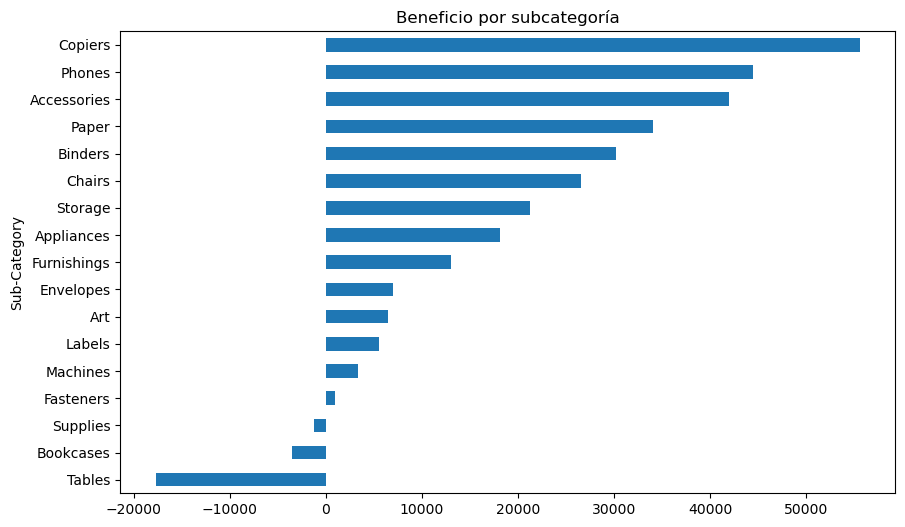

In [21]:
df.groupby("Sub-Category")["Profit"].sum().sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Beneficio por subcategoría")
plt.show()

## Análisis de subcategorías

Copiers es la subcategoría más rentable.

Tables y Bookcases presentan beneficios negativos, lo que indica posibles problemas de rentabilidad.

## Evolución de ventas

In [22]:
df.groupby("Year")["Sales"].sum()

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

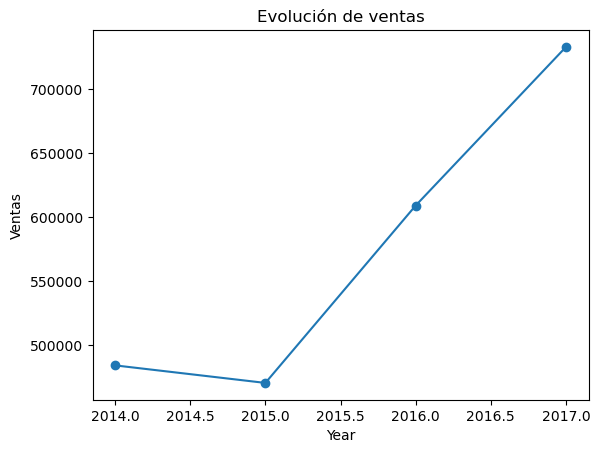

In [23]:
df.groupby("Year")["Sales"].sum().plot(
    kind="line",
    marker="o"
)

plt.title("Evolución de ventas")
plt.ylabel("Ventas")
plt.show()

## Evolución temporal

Las ventas muestran una tendencia creciente durante el periodo analizado.

El año 2017 registra el mayor volumen de ventas.

## Impacto de los descuentos

In [24]:
discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

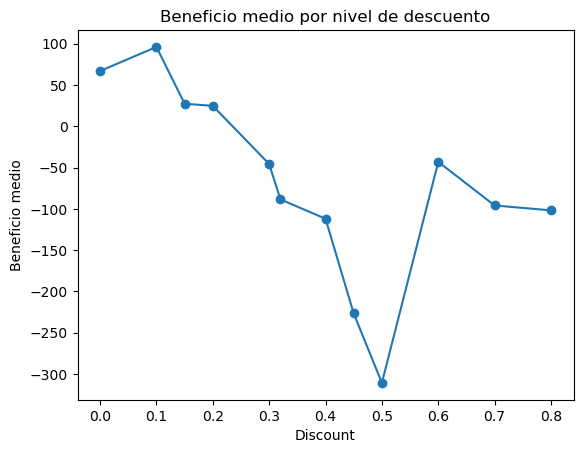

In [25]:
discount_profit.plot(
    kind="line",
    marker="o"
)

plt.title("Beneficio medio por nivel de descuento")
plt.ylabel("Beneficio medio")
plt.show()

## Impacto de los descuentos

Los descuentos bajos mantienen beneficios positivos.

A partir de descuentos cercanos al 30%, el beneficio medio se vuelve negativo.

Los descuentos elevados parecen afectar negativamente a la rentabilidad.

## Análisis regional

In [26]:
region_analysis = df.groupby("Region")[["Sales","Profit"]].sum()

region_analysis["Profit_Margin"] = (
    region_analysis["Profit"] /
    region_analysis["Sales"]
) * 100

region_analysis.sort_values(
    "Profit_Margin",
    ascending=False
)

,Sales,Profit,Profit_Margin
Region,,,
West,725457.8245,108418.4489,14.944831
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
Central,501239.8908,39706.3625,7.921629


## Análisis regional

West presenta el mejor margen de beneficio.

Central muestra el margen más bajo, por lo que podría ser una región con oportunidades de mejora.

## Segmentos de clientes

In [27]:
df.groupby("Segment")[["Sales","Profit"]].sum().sort_values(
    "Sales",
    ascending=False
)

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


## Segmentos de clientes

Consumer es el segmento que genera más ventas y beneficios.

Corporate y Home Office presentan menores volúmenes de negocio.

# Conclusiones

- Technology es la categoría con mejores resultados en ventas y beneficios.
- Furniture presenta problemas de rentabilidad.
- Tables y Bookcases generan pérdidas.
- Las ventas aumentan de forma constante durante el periodo analizado.
- Los descuentos elevados reducen significativamente el beneficio.
- La región West presenta el mejor rendimiento económico.